# Análisis de Mercado de Viajes Compartidos: Zuber (Chicago)

## Contexto del Negocio
Zuber es una nueva empresa de viajes compartidos que se está lanzando en el mercado competitivo de Chicago. Este proyecto busca identificar patrones en el comportamiento de los pasajeros y evaluar cómo los factores externos (como las empresas competidoras y las condiciones climatológicas) impactan la demanda del servicio.

## Objetivos del Proyecto
Realizar un análisis exploratorio de datos (EDA), identificar los 10 barrios principales de destino y validar el impacto del clima en la duración de los trayectos mediante pruebas estadísticas de hipótesis.

## Descripción de los datos

Se trabajará con tres conjuntos de datos obtenidos previamente mediante consultas SQL:

### trips
- company_name: nombre de la empresa de taxis.
- trips_amount: número de viajes realizados por cada compañía durante el 15 y 16 de noviembre de 2017.

### end_trips
- dropoff_location_name: barrio donde finalizó el viaje.
- average_trips: promedio de viajes finalizados en el barrio durante noviembre de 2017.

### clima
- start_ts: fecha y hora de inicio del viaje.
- weather_conditions: condiciones climáticas al inicio del viaje.
- duration_seconds: duración del viaje en segundos.

# Inicialización

Inicializar el entorno de trabajo, cargando librerías y la carga de datos

In [26]:
# Cargar librerias
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import numpy as np

In [27]:
# Cargar datos

trips = pd.read_csv('data/project_sql_result_01.csv')
end_trips = pd.read_csv('data/project_sql_result_04.csv')
clima = pd.read_csv('data/project_sql_result_07.csv')

## Preparación y validación de datos

Antes de realizar el análisis exploratorio se verificará:

- Presencia de valores ausentes.
- Registros duplicados.
- Consistencia de los tipos de datos.
- Posibles transformaciones necesarias para el análisis.

In [28]:
trips.info()
print(f"Datos duplicados: {trips.duplicated().sum()}")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 64 entries, 0 to 63
Data columns (total 2 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   company_name  64 non-null     object
 1   trips_amount  64 non-null     int64 
dtypes: int64(1), object(1)
memory usage: 1.1+ KB
Datos duplicados: 0


In [29]:
trips.head()

,company_name,trips_amount
0,Flash Cab,19558
1,Taxi Affiliation Services,11422
2,Medallion Leasin,10367
3,Yellow Cab,9888
4,Taxi Affiliation Service Yellow,9299


In [30]:
end_trips.info()
print(f"Datos duplicados: {end_trips.duplicated().sum()}")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 94 entries, 0 to 93
Data columns (total 2 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   dropoff_location_name  94 non-null     object 
 1   average_trips          94 non-null     float64
dtypes: float64(1), object(1)
memory usage: 1.6+ KB
Datos duplicados: 0


In [31]:
end_trips.head()

,dropoff_location_name,average_trips
0,Loop,10727.466667
1,River North,9523.666667
2,Streeterville,6664.666667
3,West Loop,5163.666667
4,O'Hare,2546.900000


In [32]:
clima.info()
print(f"Datos duplicados: {clima.duplicated().sum()}")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1068 entries, 0 to 1067
Data columns (total 3 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   start_ts            1068 non-null   object 
 1   weather_conditions  1068 non-null   object 
 2   duration_seconds    1068 non-null   float64
dtypes: float64(1), object(2)
memory usage: 25.2+ KB
Datos duplicados: 197


In [33]:
# Convertir start_ts a datetime
clima['start_ts'] = pd.to_datetime(clima['start_ts'])
print(clima.dtypes)

start_ts              datetime64[ns]
weather_conditions            object
duration_seconds             float64
dtype: object


### Resultados de la validación

- El conjunto trips contiene 64 registros sin valores ausentes ni duplicados.
- El conjunto end_trips contiene 94 registros sin valores ausentes ni duplicados.
- El conjunto clima contiene 1,068 registros sin valores ausentes.
- La columna start_ts fue convertida al tipo datetime para facilitar el análisis temporal.
- Se localizan 197 valores duplicados sin embargo se conservan debido a que representan viajes independientes con características similares.

## Análisis exploratorio de datos

Una vez verificada la calidad de los datos, se procede a explorar los patrones principales relacionados con:

1. Empresas de taxi con mayor número de viajes.
2. Barrios con mayor número de finalizaciones.
3. Distribución de la actividad de transporte en Chicago.

### Top 10 barrios por promedio de finalizaciones

Con el objetivo de identificar las zonas con mayor actividad de transporte, se analizan los diez barrios que registran el mayor promedio de viajes finalizados durante noviembre de 2017.

Este análisis permite reconocer los principales destinos dentro de la ciudad y comprender mejor los patrones de movilidad de los pasajeros.


In [34]:
finalizaciones_top_10 = end_trips.sort_values('average_trips', ascending=False).head(10)
print(finalizaciones_top_10)

  dropoff_location_name  average_trips
0                  Loop   10727.466667
1           River North    9523.666667
2         Streeterville    6664.666667
3             West Loop    5163.666667
4                O'Hare    2546.900000
5             Lake View    2420.966667
6            Grant Park    2068.533333
7         Museum Campus    1510.000000
8            Gold Coast    1364.233333
9    Sheffield & DePaul    1259.766667


* Visualizar en gráficos: empresas de taxis y número de viajes, los 10 barrios principales por número de finalizaciones

In [35]:
top_10_empresas = trips.sort_values('trips_amount', ascending=False).head(10)
print(top_10_empresas)

                        company_name  trips_amount
0                          Flash Cab         19558
1          Taxi Affiliation Services         11422
2                   Medallion Leasin         10367
3                         Yellow Cab          9888
4    Taxi Affiliation Service Yellow          9299
5          Chicago Carriage Cab Corp          9181
6                       City Service          8448
7                           Sun Taxi          7701
8          Star North Management LLC          7455
9  Blue Ribbon Taxi Association Inc.          5953


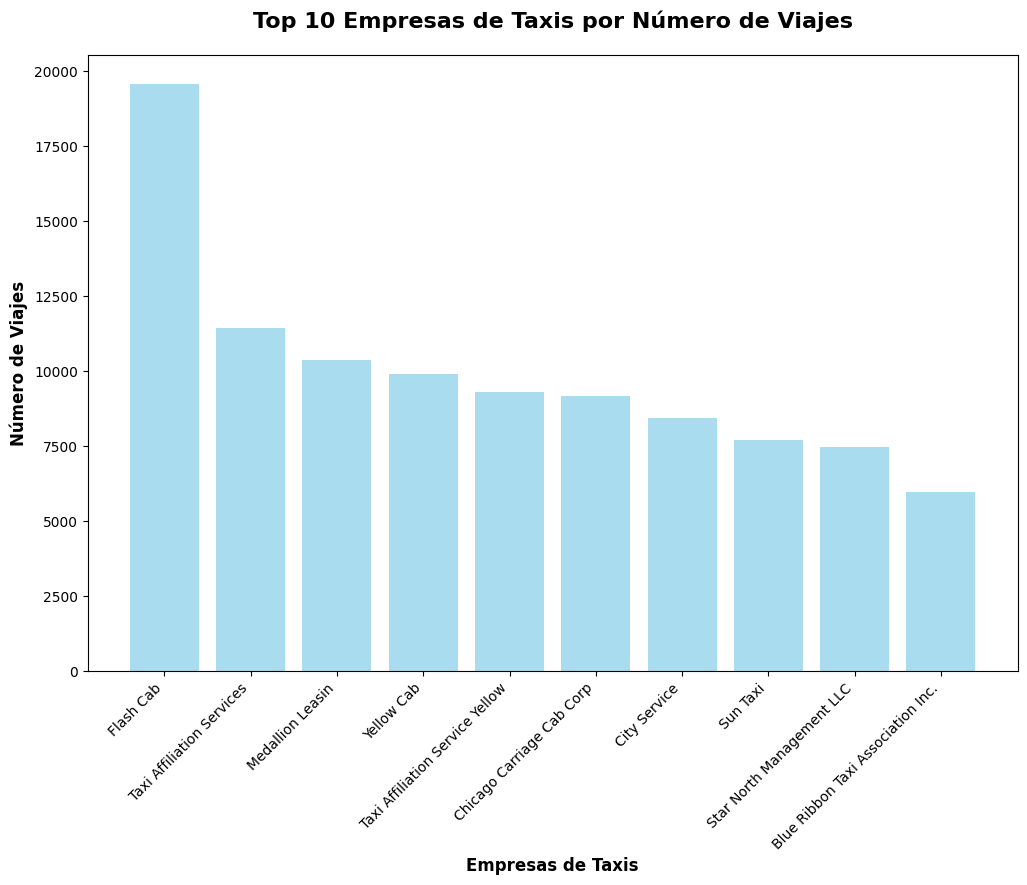

In [36]:
# Creación de gráfico de barras de las empresas y el número de viajes

plt.figure(figsize=(12, 8))
plt.bar(range(len(top_10_empresas)),
        top_10_empresas['trips_amount'],
        color='skyblue',
        alpha=0.7)
plt.title('Top 10 Empresas de Taxis por Número de Viajes', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Empresas de Taxis', fontsize=12, fontweight='bold')
plt.ylabel('Número de Viajes', fontsize=12, fontweight='bold')
plt.xticks(range(len(top_10_empresas)),
          top_10_empresas['company_name'],
          rotation=45, ha='right')
plt.show()

### Análisis de las empresas de taxis

El gráfico muestra una distribución desigual en la cantidad de viajes realizados por las compañías de taxis durante el periodo analizado.

Flash Cab lidera claramente el mercado con 19,558 viajes, seguida por Taxi Affiliation Services con 11,422 viajes y Medallion Leasing con 10,367 viajes. La diferencia entre Flash Cab y sus competidores más cercanos sugiere una posición dominante dentro del mercado de transporte de Chicago.

Aunque varias compañías presentan niveles de actividad similares, existe una concentración importante de viajes en un grupo reducido de empresas, lo que indica una participación de mercado significativamente mayor para los principales operadores.

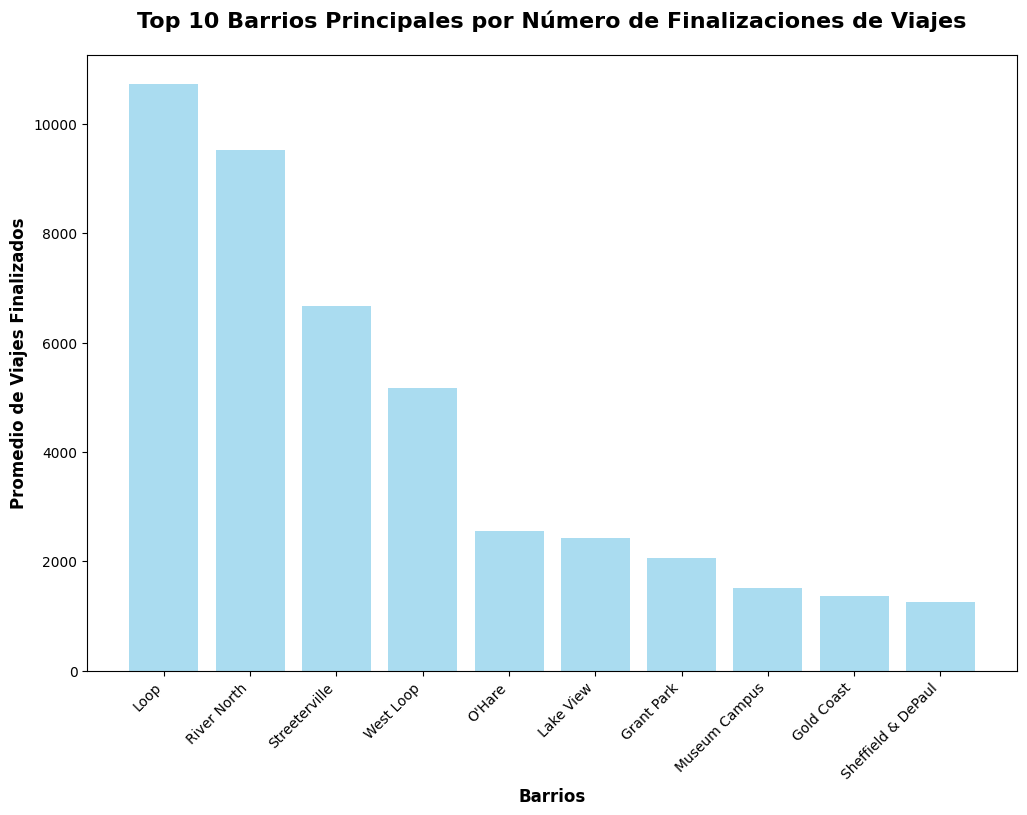

In [37]:
# Creación de gráfico de barras de los 10 barrios principales por número de finalizaciones

plt.figure(figsize=(12, 8))
plt.bar(range(len(finalizaciones_top_10)),
        finalizaciones_top_10['average_trips'],
        color='skyblue',
        alpha=0.7)
plt.title('Top 10 Barrios Principales por Número de Finalizaciones de Viajes', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Barrios', fontsize=12, fontweight='bold')
plt.ylabel('Promedio de Viajes Finalizados', fontsize=12, fontweight='bold')
plt.xticks(range(len(finalizaciones_top_10)),
          finalizaciones_top_10['dropoff_location_name'],
          rotation=45, ha='right')
plt.show()

### Análisis de los principales destinos

Los resultados muestran que Loop es el barrio con el mayor promedio de viajes finalizados, seguido por River North, Streeterville y West Loop.

La diferencia observada entre estos barrios y el resto de los destinos sugiere una mayor concentración de actividad económica, comercial y turística en estas zonas. Asimismo, la presencia de O'Hare dentro de los diez principales destinos confirma la importancia del aeropuerto como uno de los puntos de movilidad más relevantes de la ciudad.

En conjunto, estos resultados indican que la demanda de transporte se concentra en un número reducido de barrios estratégicos dentro de Chicago.


# Prueba de Hipótesis

Después de explorar la actividad de las compañías de taxis y los principales destinos de viaje, se analizará el posible efecto de las condiciones climáticas sobre la duración de los trayectos.

Específicamente, se evaluará si la duración promedio de los viajes realizados desde Loop hacia el Aeropuerto Internacional O'Hare presenta diferencias significativas durante los sábados lluviosos.

### Declaración de Hipótesis

Hipótesis Nula (H₀): La duración promedio de los viajes desde el Loop hasta el Aeropuerto Internacional O'Hare NO cambia los sábados lluviosos

Hipótesis Alternativa (H₁): La duración promedio de los viajes desde el Loop hasta el Aeropuerto Internacional O'Hare SÍ cambia los sábados lluviosos

Nivel de significancia (alpha): 0.05


### Criterio de prueba estadística

Se usará la prueba de t de Student para muestras independientes.
¿Por qué?
1. Comparamos medidas de dos grupos independientes.
2. Existe una variable continua que es la duración en segundos.
3. Grupos independientes: sábados lluviosos VS no lluviosos

In [38]:
# Crear columna day_of_week para incorporar el día de la semana. 
# Validar valores únicos

clima['day_of_week'] = clima['start_ts'].dt.dayofweek
print('Día de la semana:', clima['day_of_week'].unique())

Día de la semana: [5]


In [39]:
# Separar en 2 grupos según las condiciones climáticas

grupo_lluvioso = clima[clima['weather_conditions'] == 'Bad']['duration_seconds']
grupo_no_lluvioso = clima[clima['weather_conditions'] == 'Good']['duration_seconds']

print(f'Viajes en sábados NO lluviosos: {len(grupo_no_lluvioso)}')
print(f'Viajes en sábados lluviosos: {len(grupo_lluvioso)}')
print(f'Total de viajes: {len(clima)}')

Viajes en sábados NO lluviosos: 888
Viajes en sábados lluviosos: 180
Total de viajes: 1068


In [40]:
# Estadística descriptivas de cada grupo

print("=== ESTADÍSTICAS DESCRIPTIVAS ===")
print(f"\nGrupo NO lluvioso:")
print(f"  Media: {grupo_no_lluvioso.mean():.2f} segundos")
print(f"  Desviación estándar: {grupo_no_lluvioso.std():.2f} segundos")
print(f"  Mediana: {grupo_no_lluvioso.median():.2f} segundos")

print(f"\nGrupo lluvioso:")
print(f"  Media: {grupo_lluvioso.mean():.2f} segundos")
print(f"  Desviación estándar: {grupo_lluvioso.std():.2f} segundos")
print(f"  Mediana: {grupo_lluvioso.median():.2f} segundos")


=== ESTADÍSTICAS DESCRIPTIVAS ===

Grupo NO lluvioso:
  Media: 1999.68 segundos
  Desviación estándar: 759.20 segundos
  Mediana: 1800.00 segundos

Grupo lluvioso:
  Media: 2427.21 segundos
  Desviación estándar: 721.31 segundos
  Mediana: 2540.00 segundos



Los viajes realizados bajo condiciones climáticas desfavorables presentan una duración promedio superior a la observada durante condiciones climáticas favorables.

Mientras que los viajes en condiciones favorables registran una duración promedio cercana a 2,000 segundos, los viajes realizados durante lluvia alcanzan aproximadamente 2,427 segundos. Esta diferencia preliminar sugiere que el clima podría influir en los tiempos de traslado, aunque será necesario confirmarlo mediante una prueba estadística.

In [ ]:
# Prueba t para muestras independientes
t_stat, p_value = stats.ttest_ind(grupo_no_lluvioso, grupo_lluvioso)
# Nivel de significancia
alpha = 0.05
if p_value < alpha:
    print(f"\nConclusión: p-value ({p_value:.6f}) < α ({alpha})")
    print("Rechazamos H₀: Existe evidencia estadística de que el tiempo promedio de los viajes desde el Loop hasta el Aeropuerto cambian los sábados lluviosos")
else:
    print(f"\nConclusión: p-value ({p_value:.6f}) >= α ({alpha})")
    print("No rechazamos H₀: No hay evidencia suficiente de que el tiempo promedio de los viajes cambia cuando llueve")
print()
print("===RESULTADOS DE LA PRUEBA T===")
print(f'Estadístico t: {t_stat:4f}')
print(f'Valor p: {p_value:.6f}')
print(f'Nivel de significación (α): {alpha}"')


Conclusión: p-value (0.000000) < α (0.05)
Rechazamos H₀: Existe evidencia estadística de que el tiempo promedio de los viajes desde el Loop hasta el Aeropuerto cambian los sábados lluviosos

===RESULTADOS DE LA PRUEBA T===
Estadístico t: -6.946178
Valor p: 0.000000
Nivel de significación (α): 0.05"


### Conclusiones de la prueba de hipótesis

Se aplicó una prueba t de Student para comparar la duración promedio de los viajes realizados durante sábados con condiciones climáticas favorables y desfavorables.

Los resultados obtenidos muestran una diferencia estadísticamente significativa entre ambos grupos (t = -6.95, p < 0.05). Debido a que el valor p es considerablemente menor que el nivel de significancia establecido (α = 0.05), se rechaza la hipótesis nula.

Además, los viajes realizados durante condiciones lluviosas presentan una duración promedio aproximadamente 427.53 segundos mayor, equivalente a 7.13 minutos adicionales respecto a los viajes realizados en condiciones favorables.

Por lo tanto, existe evidencia estadística suficiente para concluir que las condiciones climáticas afectan la duración de los viajes desde Loop hacia el Aeropuerto Internacional O'Hare.

### Conclusiones generales

De acuerdo al análisis podemos visualizar que las preferencias de los pasajeros para viajar, se concentra con la empresa Flash Cab y los principales barrios a los que acuden es Loop, River North y Streeterville. 
Podemos visualizar que la duración promedio de los viajes aumentan aproximadamente 7 minutos en sábados lluviosos


## Conclusiones generales

El análisis permitió identificar patrones relevantes en la operación del servicio de taxis en Chicago durante noviembre de 2017.

En primer lugar, se observó una fuerte concentración de viajes en un número reducido de compañías, siendo Flash Cab la empresa con mayor actividad durante el periodo analizado.

Respecto a los destinos, los barrios de Loop, River North y Streeterville registraron los mayores promedios de finalización de viajes, lo que sugiere que estas zonas concentran una parte importante de la actividad económica y de movilidad de la ciudad.

Finalmente, la prueba de hipótesis demostró que las condiciones climáticas tienen un impacto significativo en la duración de los viajes entre Loop y el Aeropuerto Internacional O'Hare. Los trayectos realizados durante sábados lluviosos presentan tiempos promedio superiores a los observados en condiciones favorables.

Estos hallazgos pueden contribuir a una mejor comprensión de la demanda de transporte y de los factores externos que afectan la operación de los servicios de movilidad urbana.